# Nijmegen Floods - Non-Parametric Bayesian Networks

## 0. Importing packages and functions

### Importing necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from py_banshee.rankcorr import bn_rankcorr
from py_banshee.copula_test import cvm_statistic
from py_banshee.sample_bn import generate_samples
from py_banshee.bn_plot import bn_visualize
from py_banshee.d_cal import test_distance
from py_banshee.prediction import inference

### Defining functions

In [2]:
# --- Defining functions ---
def unity(data):
    u_hat = stats.rankdata(data, method='average', axis=0)
    u_hat = u_hat / (data.shape[0] + 1)
    return pd.DataFrame(u_hat, columns=data.columns)

def sd_normal(data):
    u_hat = stats.rankdata(data, method='average', axis=0) / (len(data) + 1)
    sd_data = stats.norm.ppf(u_hat) # norm.ppf is the inverse of the CDF!!
    return sd_data

def compile_era5_snowmelt(root_folder_path, output_csv="era5_snowmelt_data.csv"):

    all_dataframes = []
    
    if not os.path.exists(root_folder_path):
        print(f"Error: The folder '{root_folder_path}' does not exist.")
        return None

    sorted_folders = sorted(os.listdir(root_folder_path))

    for folder_name in sorted_folders:
        dir_path = os.path.join(root_folder_path, folder_name)

        if os.path.isdir(dir_path) and len(folder_name) == 2 and folder_name.isdigit():
            short_year = int(folder_name)
            if short_year < 50:
                full_year = f"20{folder_name}"
            else:
                full_year = f"19{folder_name}"
            
            file_name = f"era5_waves_{full_year}.nc"
            file_path = os.path.join(dir_path, file_name)

            if os.path.exists(file_path):
                try:
                    with xr.open_dataset(file_path) as ds:
                        df = ds.to_dataframe().reset_index()
                        df['source_year'] = full_year
                        all_dataframes.append(df)
                        
                except Exception as e:
                    print(f"Failed to read {file_name}: {e}")
            else:
                print(f"Warning: File {file_name} not found in folder {folder_name}")

    if all_dataframes:
        df_snowmelt = pd.concat(all_dataframes, ignore_index=True)
        df_snowmelt.to_csv(output_csv, index=False)
        return df_snowmelt
    else:
        print("No valid data found.")
        return pd.DataFrame()

## 1. Environmental Variables

The following environmental variables are extracted and used for the NPBN analysis:
- $Q$: River discharge of the river Waal
- $T$: Temperature in the alps (Grimsel Hospiz station - Switserland)
- $P$: Precipitation in Düsseldorf
- $GW$: Groundwater levels near Nijmegen (Wijchen)

All data is imported from different data file-types, and resampled to daily mean values.

### River Discharge

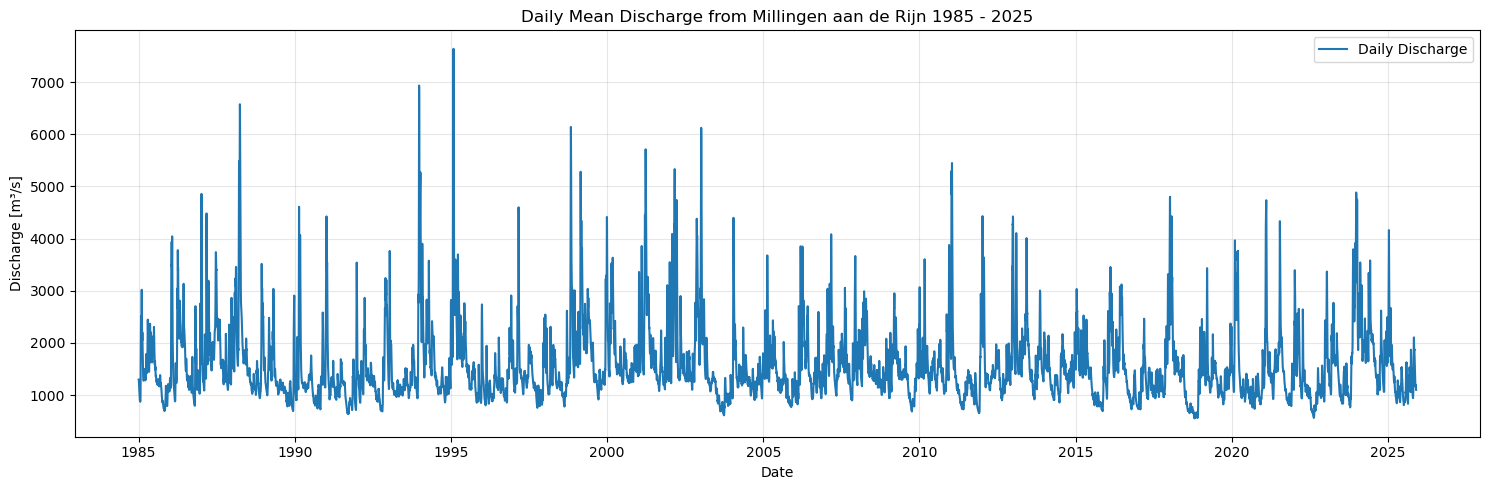

In [3]:
discharge_files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

df_discharge = []

for file_name in discharge_files:
    df = pd.read_csv(file_name, sep=';')

    df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)                        # convert to datetime     
    df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))    # convert to numeric
    df.loc[df["waarde"] > 1e5, "waarde"] = np.nan                                   # remove outliers
    df = df.dropna(subset=["datum", "waarde"])                                      # drop rows with NaN

    # Resample to daily mean
    daily_part = df.groupby("datum")["waarde"].mean()
    df_discharge.append(daily_part)

df_discharge = pd.concat(df_discharge).sort_index()


plt.figure(figsize=(15, 5))
plt.plot(df_discharge.index, df_discharge.values, label = "Daily Discharge")
plt.xlabel("Date")
plt.ylabel("Discharge [m³/s]")
plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()


### Temperature Alps

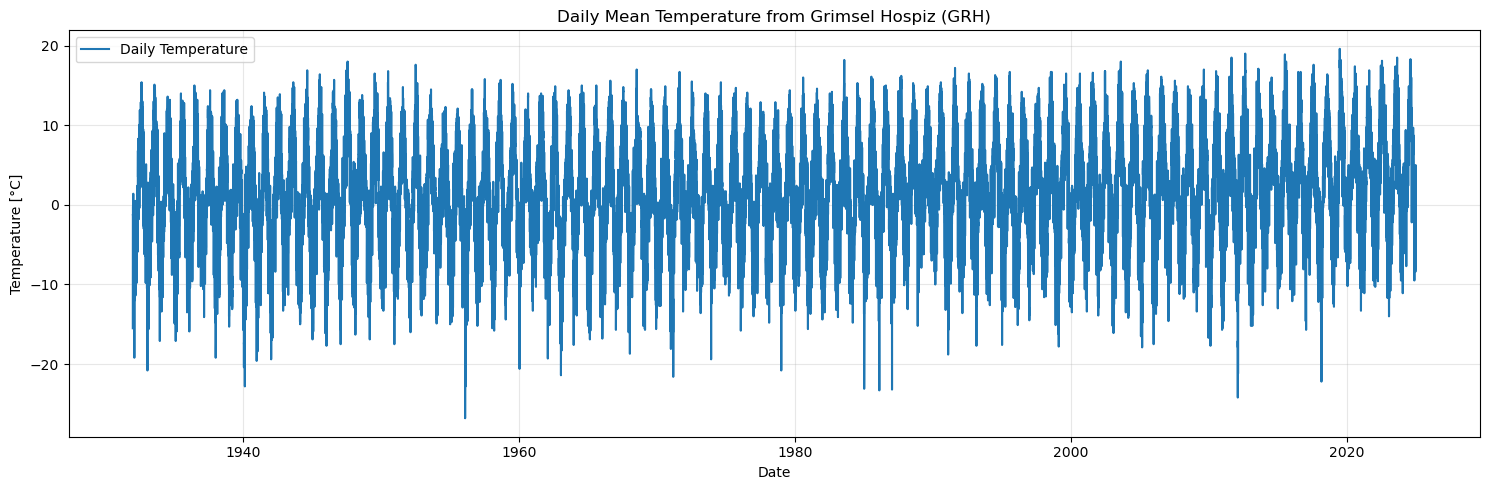

In [4]:
temperature_file = 'data/ogd-nbcn_grh_d_historical.csv'

df_temperature = pd.read_csv(temperature_file, sep=';')
df_temperature["datum"] = pd.to_datetime(df_temperature["reference_timestamp"], dayfirst=True)
df_temperature["temperature"] = pd.to_numeric(df_temperature["ths200d0"].astype(str).str.replace(",", "."))
df_temperature = df_temperature.dropna(subset=["datum", "temperature"])
df_temperature = df_temperature.set_index("datum").sort_index()

plt.figure(figsize=(15, 5))
plt.plot(df_temperature.index, df_temperature["temperature"].values, label = "Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature [°C]")
plt.title(f"Daily Mean Temperature from Grimsel Hospiz (GRH)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

### Precipitation

/var/folders/4r/myg3jzhx1yd72kbqs5r4rv2w0000gn/T/ipykernel_32692/2757820325.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_precipitation = pd.read_csv(precipitation_file, sep=',', quoting=3, dtype=str, encoding='latin1', index_col=False)


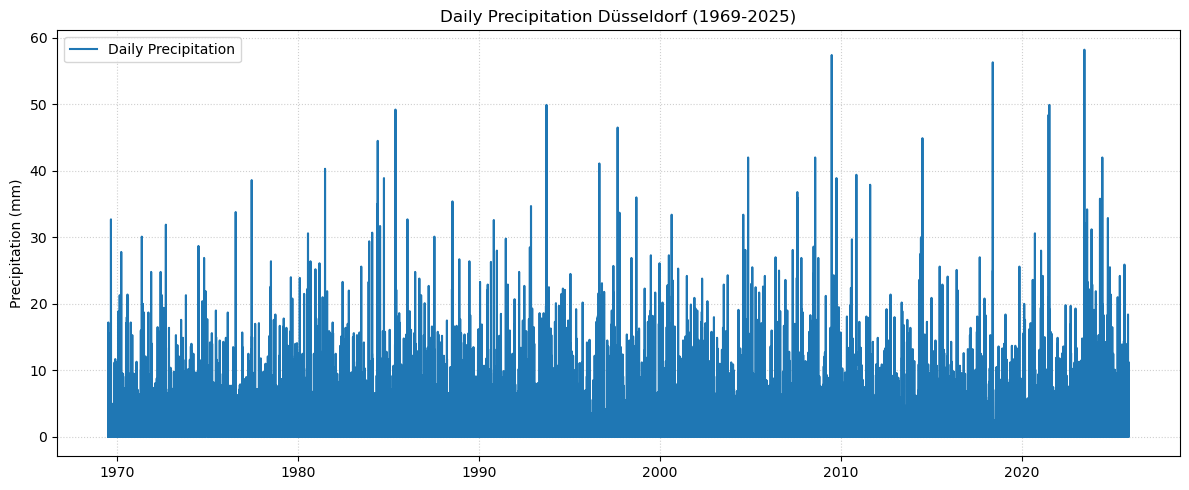

In [5]:
precipitation_file = 'data/dusseldorf_precipitation.csv'

df_precipitation = pd.read_csv(precipitation_file, sep=',', quoting=3, dtype=str, encoding='latin1', index_col=False)
df_precipitation.columns = df_precipitation.columns.str.replace('"', '').str.strip()
df_precipitation = df_precipitation.replace('"', '', regex=True)

date_col = 'Zeitstempel'
val_col = 'Wert'

df_precipitation[date_col] = pd.to_datetime(df_precipitation[date_col], format='%Y-%m-%d', errors='coerce')
df_precipitation[val_col] = pd.to_numeric(df_precipitation[val_col], errors='coerce')

df_precipitation = df_precipitation.dropna(subset=[date_col, val_col])
df_precipitation.set_index(date_col, inplace=True)
df_precipitation = df_precipitation[df_precipitation[val_col] >= 0]  
df_precipitation = df_precipitation.asfreq('D', fill_value=0.0)

# 5. Plotting
plt.figure(figsize=(12, 5))
plt.plot(df_precipitation.index, df_precipitation[val_col], label='Daily Precipitation')

plt.title(f'Daily Precipitation Düsseldorf ({df_precipitation.index.year.min()}-{df_precipitation.index.year.max()})')
plt.ylabel('Precipitation (mm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### Groundwater Level

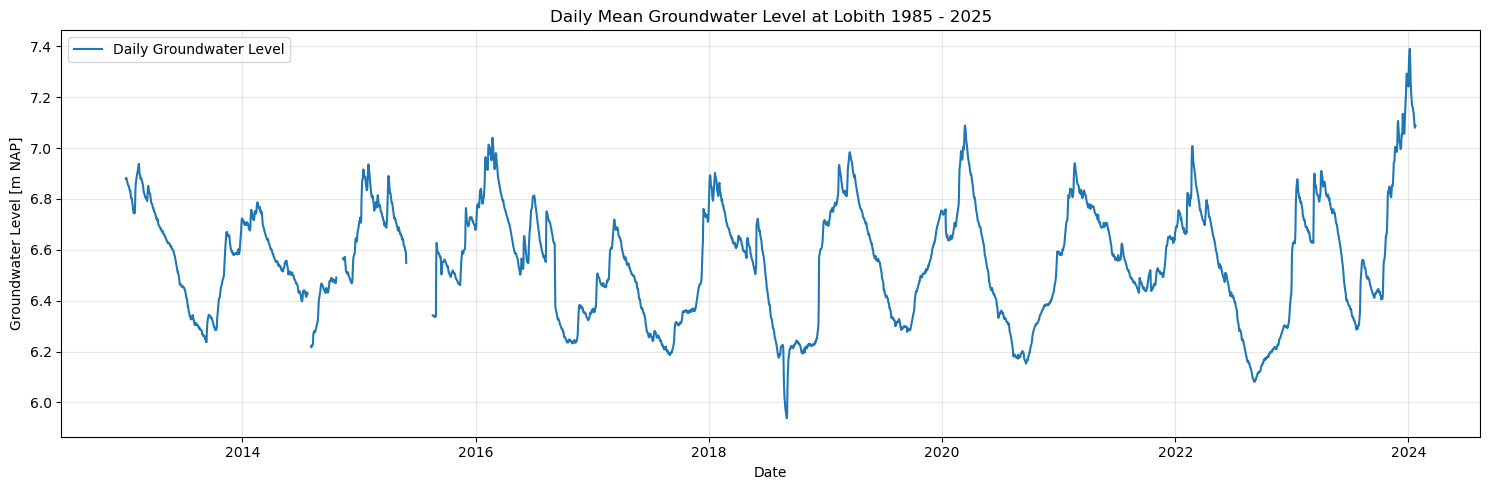

In [6]:
groundwater_file = 'data/groundwater.csv'

df_gw = pd.read_csv(groundwater_file, delimiter=';')
df_gw['meetwaarde (m NAP)'] = df_gw['meetwaarde (m NAP)'] / 100
df_gw['date'] = pd.to_datetime(df_gw['datum'] + ' ' + df_gw['tijd'], dayfirst=True)
df_gw = df_gw.set_index('date')
df_gw = df_gw.drop(columns=['datum', 'tijd'])
df_gw = df_gw.resample('D').mean()

plt.figure(figsize=(15, 5))
plt.plot(df_gw.index, df_gw['meetwaarde (m NAP)'], label = "Daily Groundwater Level")
plt.xlabel("Date")
plt.ylabel("Groundwater Level [m NAP]")
plt.title("Daily Mean Groundwater Level at Lobith 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

### Combine Datasets into One Single Dataframe

To effectively combine all datasets into one single dataframe, the overlapping datapoints have to be found. 

In [7]:
def get_clean_series(data, new_name):
    """
    Takes a DataFrame, Series, or List and returns a clean, named Series.
    Handles grouping duplicates automatically.
    """

    # Handle Duplicates (Group by Date)
    grouped = data.groupby(level=0).mean(numeric_only=True)
    
    # Extract Values
    if isinstance(grouped, pd.DataFrame):
        # Verify we have numeric columns left
        if grouped.shape[1] > 0:
            s = grouped.iloc[:, 0]
        else:
            # Fallback for empty or non-numeric frames
            return pd.Series(name=new_name, dtype='float64')
    else:
        s = grouped
        
    return s.rename(new_name)

s_discharge = get_clean_series(df_discharge, "Discharge_m3s")
s_temp      = get_clean_series(df_temperature, "Temperature_C")
s_precip    = get_clean_series(df_precipitation, "Precipitation_mm")
s_ground    = get_clean_series(df_gw, "Groundwater_m")

df_final = pd.concat([s_discharge, s_temp, s_precip, s_ground], axis=1)
df_final = df_final.sort_index()
df_final = df_final.dropna()

## 2. NPBN Analysis

### DAG (Directed Acyclic Graph)

In [8]:
N = df_final.shape[1] 
parents1 = [None]*N  

parents1[0] = []   # Discharge has no parents       
parents1[1] = [0]  # Temperature is the parent of Discharge          
parents1[2] = [0]  # Precipitation is the parent of Discharge    
parents1[3] = [0]  # Groundwater is the parent of Discharge

### No time lag correlation analysis

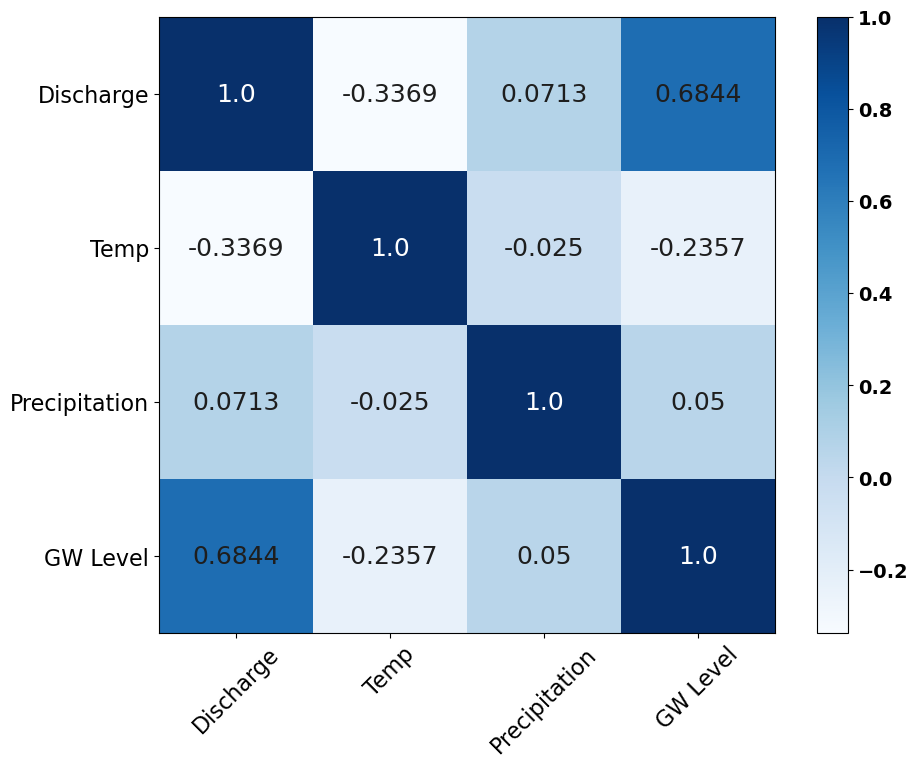

In [9]:
R_BN_1 = bn_rankcorr(parents1, df_final, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

### Time Lag correlation analysis

#### Optimal time lag calculation

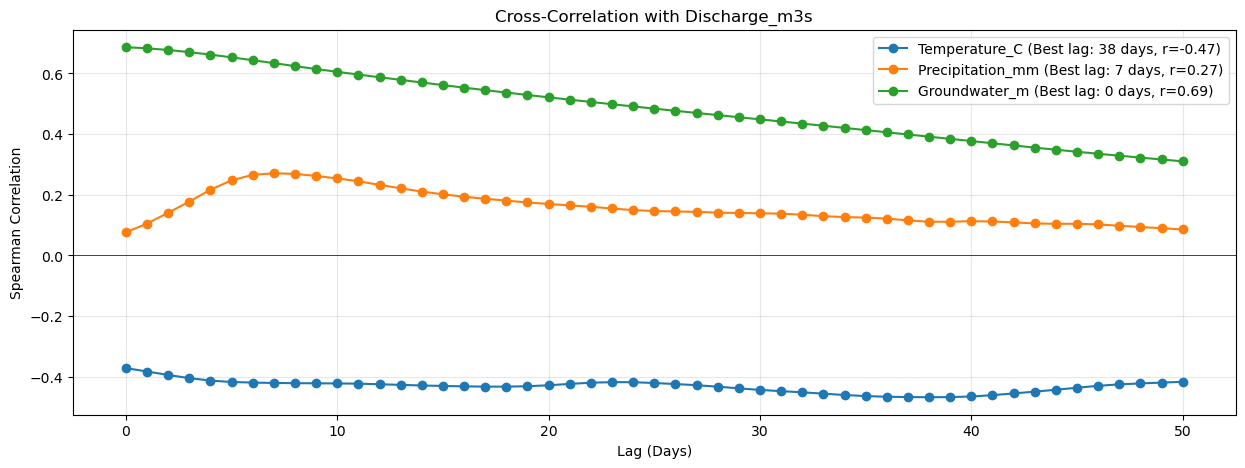

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Precipitation_mm: 7 days
 - Groundwater_m: 0 days


In [10]:
def analyze_lag(df, target, parent, max_lag=50):
    lags = range(max_lag + 1)
    correlations = []
    
    for lag in lags:
        shifted_parent = df[parent].shift(lag)
        corr = df[target].corr(shifted_parent, method='spearman')
        correlations.append(corr)
        
    abs_corrs = [abs(c) for c in correlations]
    best_lag = abs_corrs.index(max(abs_corrs))
    best_corr = correlations[best_lag]
    
    return lags, correlations, best_lag, best_corr

target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Precipitation_mm', 'Groundwater_m']

plt.figure(figsize=(15, 5))

best_lags = {}

for parent in parents:
    lags, corrs, best_k, max_r = analyze_lag(df_final, target_var, parent)
    best_lags[parent] = best_k
    plt.plot(lags, corrs, marker='o', label=f'{parent} (Best lag: {best_k} days, r={max_r:.2f})')

plt.title(f'Cross-Correlation with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('Spearman Correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

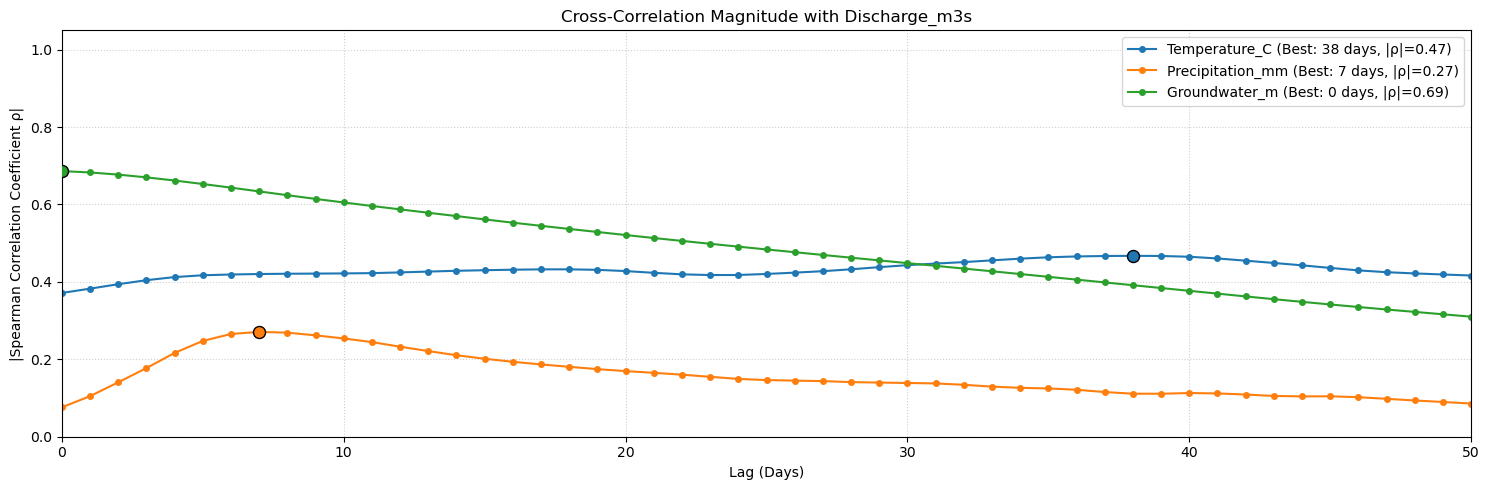

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Precipitation_mm: 7 days
 - Groundwater_m: 0 days


In [11]:
def analyze_lag(df, target, parent, max_lag=50):
    lags = range(max_lag + 1)
    correlations = []
    
    for lag in lags:
        # Shift parent data "down" by lag days
        shifted_parent = df[parent].shift(lag)
        
        # Calculate Spearman correlation
        corr = df[target].corr(shifted_parent, method='spearman')
        correlations.append(corr)
        
    # Take absolute values for analysis and plotting
    abs_corrs = [abs(c) for c in correlations]
    
    # Find best lag based on maximum ABSOLUTE correlation
    best_lag = abs_corrs.index(max(abs_corrs))
    best_corr = abs_corrs[best_lag] # This is now the absolute value
    
    return lags, abs_corrs, best_lag, best_corr

# Configuration
target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Precipitation_mm', 'Groundwater_m']

# Plotting - Changed figsize to be wider (better for time series/lags)
plt.figure(figsize=(15, 5))

best_lags = {}

for parent in parents:
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final, target_var, parent)
    best_lags[parent] = best_k
    
    # Plot the line
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    # Highlight the maximum point with a larger dot
    color = p[0].get_color() # Get the color of the line to match
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

plt.title(f'Cross-Correlation Magnitude with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 50)
plt.ylim(0, 1.05) # Fixed y-axis for cleaner look
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

#### Calculate correlations with shifted timeseries

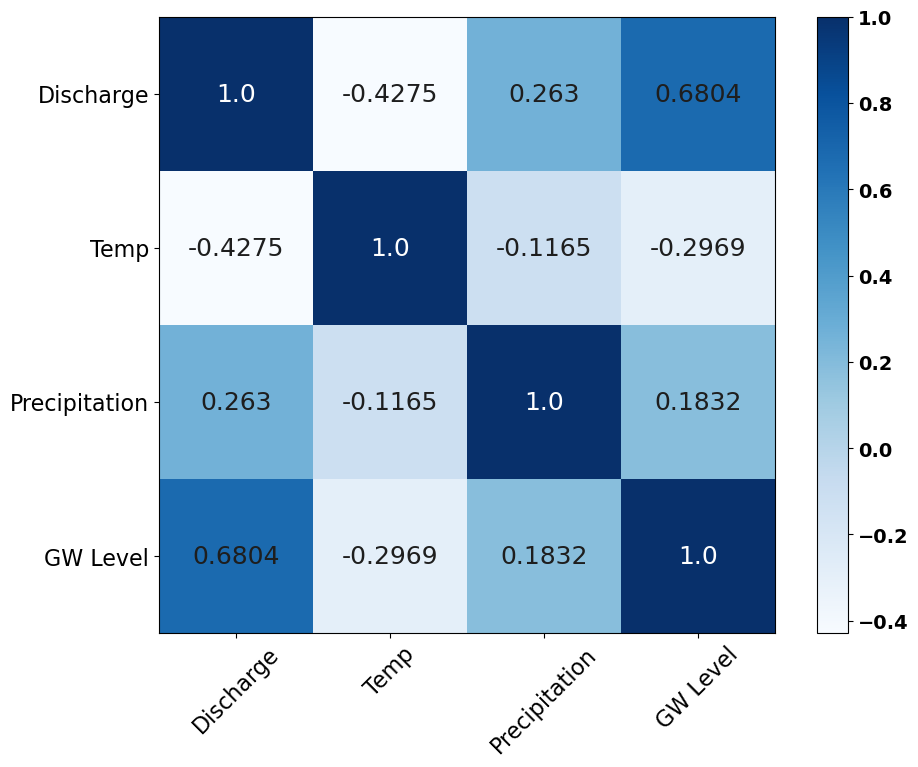

In [12]:
df_shifted = df_final.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted[col] = df_shifted[col].shift(lag)
    else:
        pass
        
df_shifted = df_shifted.dropna()

R_BN_1_shifted = bn_rankcorr(parents1, df_shifted, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

## 3. Rain with system memory 

For the analysis, the choise to incorporate system memory for precipitation is made. A period of 6 days is chosen. 

In [13]:
df_precipitation_system_memory = df_precipitation.copy()
df_precipitation_system_memory['Wert'] = df_precipitation_system_memory['Wert'].rolling(window=6, min_periods=1).sum()
s_precip_system_memory    = get_clean_series(df_precipitation_system_memory, "Wert")
df_final_system_memory = pd.concat([s_discharge, s_temp, s_precip_system_memory, s_ground], axis=1)
df_final_system_memory = df_final_system_memory.sort_index()
df_final_system_memory = df_final_system_memory.dropna()

df_final_system_memory.head()

,Discharge_m3s,Temperature_C,Wert,Groundwater_m
2013-01-01,4191.446493,-5.8,22.2,6.879375
2013-01-02,3887.455644,-11.3,13.5,6.883000
2013-01-03,3536.374827,-7.4,13.4,6.881125
2013-01-04,3183.239792,-1.1,13.0,6.872875
2013-01-05,2874.311581,-2.8,11.4,6.868875


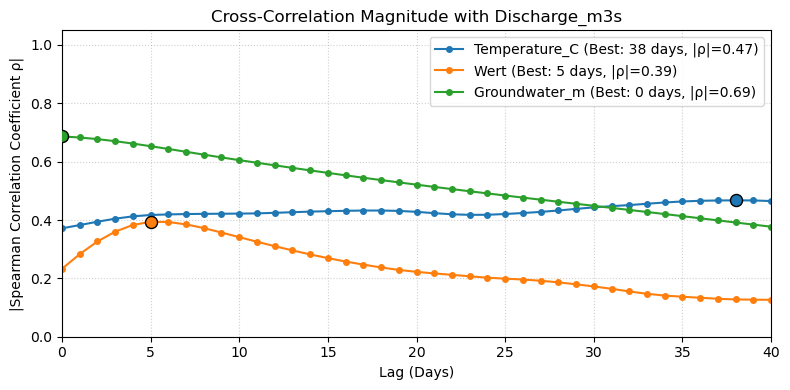

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Wert: 5 days
 - Groundwater_m: 0 days


In [14]:
target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Wert', 'Groundwater_m'] 

plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    if parent not in df_final_system_memory.columns:
        print(f"Warning: Column '{parent}' not found. Skipping.")
        continue
        
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final_system_memory, target_var, parent)
    best_lags[parent] = best_k
    
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    color = p[0].get_color()
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

plt.title(f'Cross-Correlation Magnitude with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

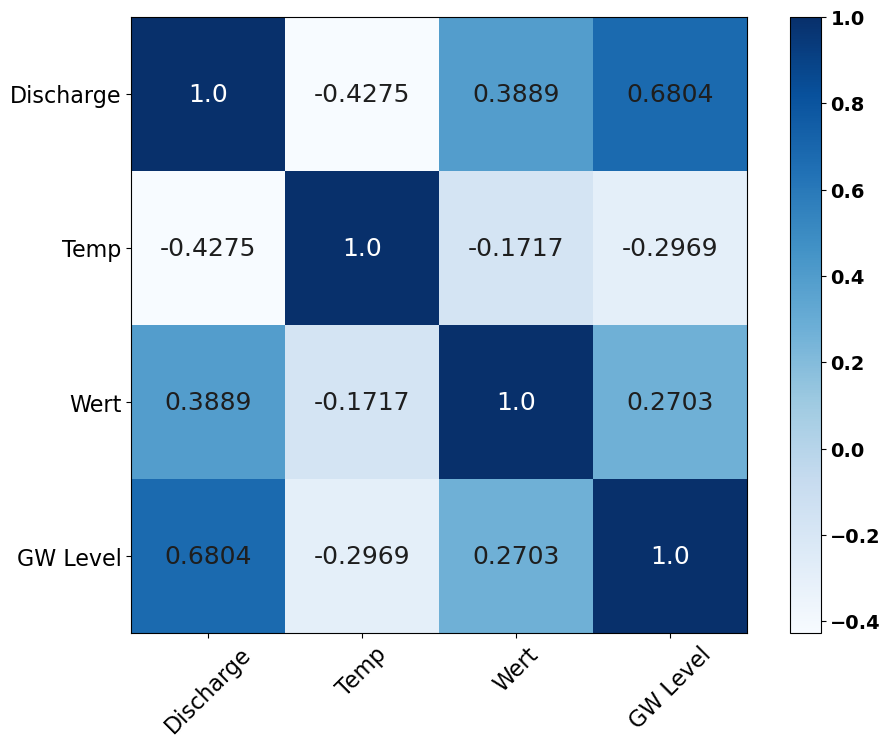

In [15]:
df_shifted_system_memory = df_final_system_memory.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted_system_memory[col] = df_shifted_system_memory[col].shift(lag)
    else:
        pass
        
df_shifted_system_memory = df_shifted_system_memory.dropna()
R_BN_1_shifted = bn_rankcorr(parents1, df_shifted_system_memory, var_names=['Discharge', 'Temp', 'Wert', 'GW Level'], is_data=True, plot=True)

## 4. Switch to Snowmelt

To find better correlations, instead of Alpine temperatures, the snow melt equivalent is chosen to find joint distributions. 

The Snowmelt data is obtained from the ERA5 single levels dataset. taken every 3 hours and resampled to daily mean values. 

In [16]:
df_snowmelt = pd.read_csv('data/era5_snowmelt_data.csv')

In [17]:
df_snowmelt['valid_time'] = pd.to_datetime(df_snowmelt['valid_time'])
df_snowmelt = df_snowmelt.drop(columns=['number', 'expver', 'source_year'], errors='ignore')
df_snowmelt = df_snowmelt.groupby('valid_time')[['smlt']].mean()
df_snowmelt = df_snowmelt.resample('D').sum()
df_snowmelt.index.name = 'date'
df_snowmelt = df_snowmelt.sort_index()
df_snowmelt['smlt'] = df_snowmelt['smlt'] * 1000            # resample to mm instead of meters

s_snowmelt = get_clean_series(df_snowmelt, "Snowmelt")

### Rolling sum for snowmelt

For the same reason as the precipitation, a rolling sum is used for snowmelt. A period of 5 days is chosen. 

In [18]:
df_snowmelt['smlt'] = df_snowmelt['smlt'].rolling(window=5, min_periods=1).sum()
s_snowmelt = get_clean_series(df_snowmelt, "Snowmelt")

df_final_seasonality = pd.concat([s_discharge, s_snowmelt, s_precip_system_memory, s_ground], axis=1)
df_final_seasonality = df_final_seasonality.rename(columns={'Wert': 'Precipitation'})
df_final_seasonality = df_final_seasonality.sort_index()
df_final_seasonality = df_final_seasonality.dropna()


## 5. New NPBN analysis

### Whole year Analysis

#### NPBN + Time lag

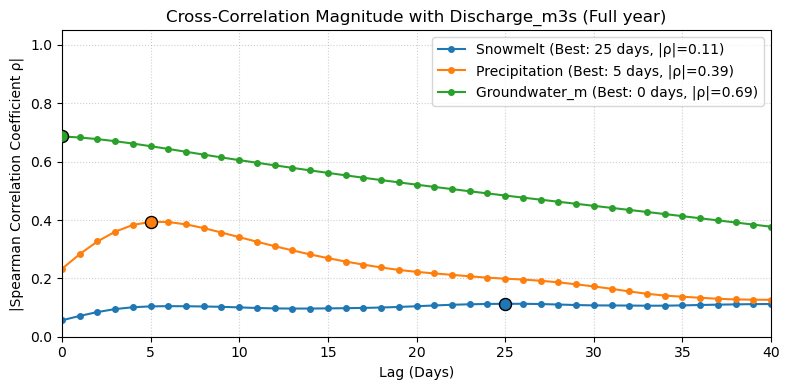

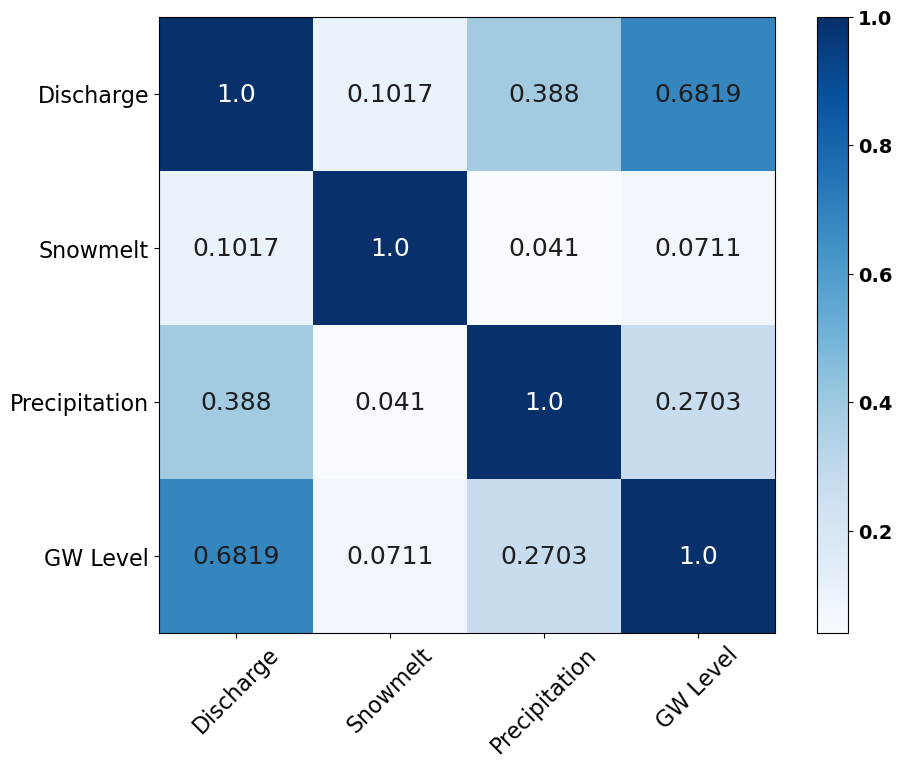

Optimal Shifts Found:
 - Snowmelt: 25 days
 - Precipitation: 5 days
 - Groundwater_m: 0 days


In [19]:
# Whole year 
N = df_final.shape[1] 
parents1 = [None]*N  

parents1[0] = []   # Discharge has no parents       
parents1[1] = [0]  # Temperature is the parent of Discharge          
parents1[2] = [0]  # Precipitation is the parent of Discharge    
parents1[3] = [0]  # Groundwater is the parent of Discharge

target_var = 'Discharge_m3s'
parents = ['Snowmelt', 'Precipitation', 'Groundwater_m'] 

plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    if parent not in df_final_seasonality.columns:
        print(f"Warning: Column '{parent}' not found. Skipping.")
        continue
        
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final_seasonality, target_var, parent)
    best_lags[parent] = best_k
    
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    color = p[0].get_color()
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

df_shifted_seasonality = df_final_seasonality.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted_seasonality[col] = df_shifted_seasonality[col].shift(lag)
    else:
        pass
        
df_shifted_seasonality = df_shifted_seasonality.dropna()
plt.title(f'Cross-Correlation Magnitude with {target_var} (Full year)')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show

R_BN_1_seasonality_full_year = bn_rankcorr(parents1, df_shifted_seasonality, var_names=['Discharge', 'Snowmelt', 'Precipitation', 'GW Level'], is_data=True, plot=True)

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")


#### CVM statistic

/Users/tijnspijkers/miniforge3/envs/copula/lib/python3.13/site-packages/pycopula/copula.py:318: RuntimeWarning: divide by zero encountered in power
  return 1. / theta**2 * t**(1. / theta - 2.) * (theta + t**(1. / theta) - 1.) * np.exp(-t**(1. / theta))
/Users/tijnspijkers/miniforge3/envs/copula/lib/python3.13/site-packages/pycopula/copula.py:365: RuntimeWarning: invalid value encountered in multiply
  return prod * invertNDerivative(sumInvert, theta, self.dim)
/Users/tijnspijkers/miniforge3/envs/copula/lib/python3.13/site-packages/pycopula/copula.py:318: RuntimeWarning: overflow encountered in power
  return 1. / theta**2 * t**(1. / theta - 2.) * (theta + t**(1. / theta) - 1.) * np.exp(-t**(1. / theta))
/Users/tijnspijkers/miniforge3/envs/copula/lib/python3.13/site-packages/pycopula/copula.py:314: RuntimeWarning: overflow encountered in multiply
  prod *= (theta / (np.log(x[i]) * x[i]))*(-np.log(x[i]))**theta
/Users/tijnspijkers/miniforge3/envs/copula/lib/python3.13/site-packages/pyco

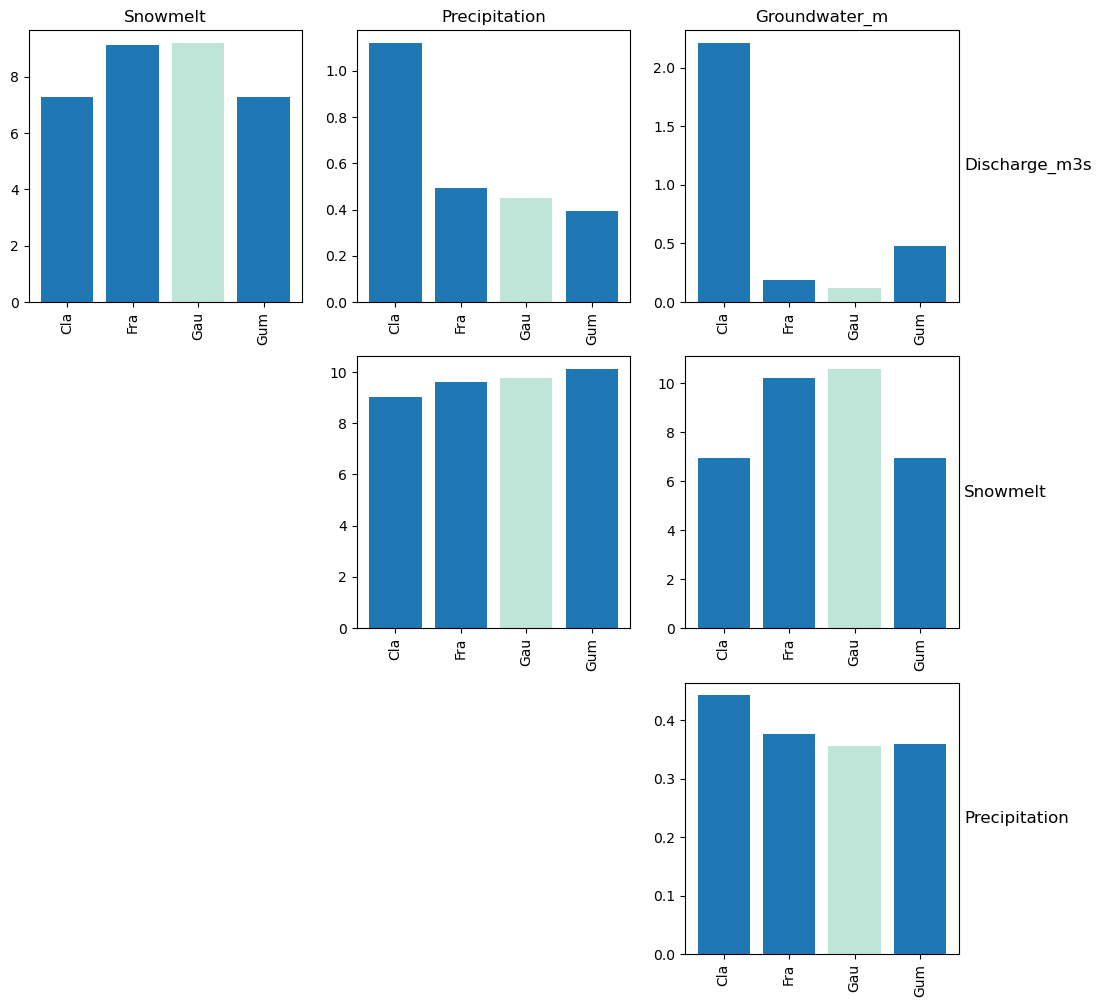

In [20]:
data = df_final_seasonality
unity_data = unity(data)

M = cvm_statistic(data, plot=1, names=data.columns,fig_name='CvM')

#### Significance testing

In [21]:
#Transform data to standard normal and store it in a DataFrame
standard_data = pd.DataFrame(sd_normal(data), columns=data.columns)

#Compute pearson correlation matrix
rho_N = np.corrcoef(standard_data, rowvar=False) # PEARSON!

#Transform to rank correlation matrix
R_N = 6 / np.pi * np.arcsin(rho_N / 2)

R_e = stats.spearmanr(data)[0]

print(f'p-value: {stats.spearmanr(data)[1]}')

p-value: [[0.00000000e+00 4.28964450e-04 2.86059300e-49 0.00000000e+00]
 [4.28964450e-04 0.00000000e+00 1.01436352e-03 1.86979201e-05]
 [2.86059300e-49 1.01436352e-03 0.00000000e+00 2.64611064e-08]
 [0.00000000e+00 1.86979201e-05 2.64611064e-08 0.00000000e+00]]


#### d-calibration scores

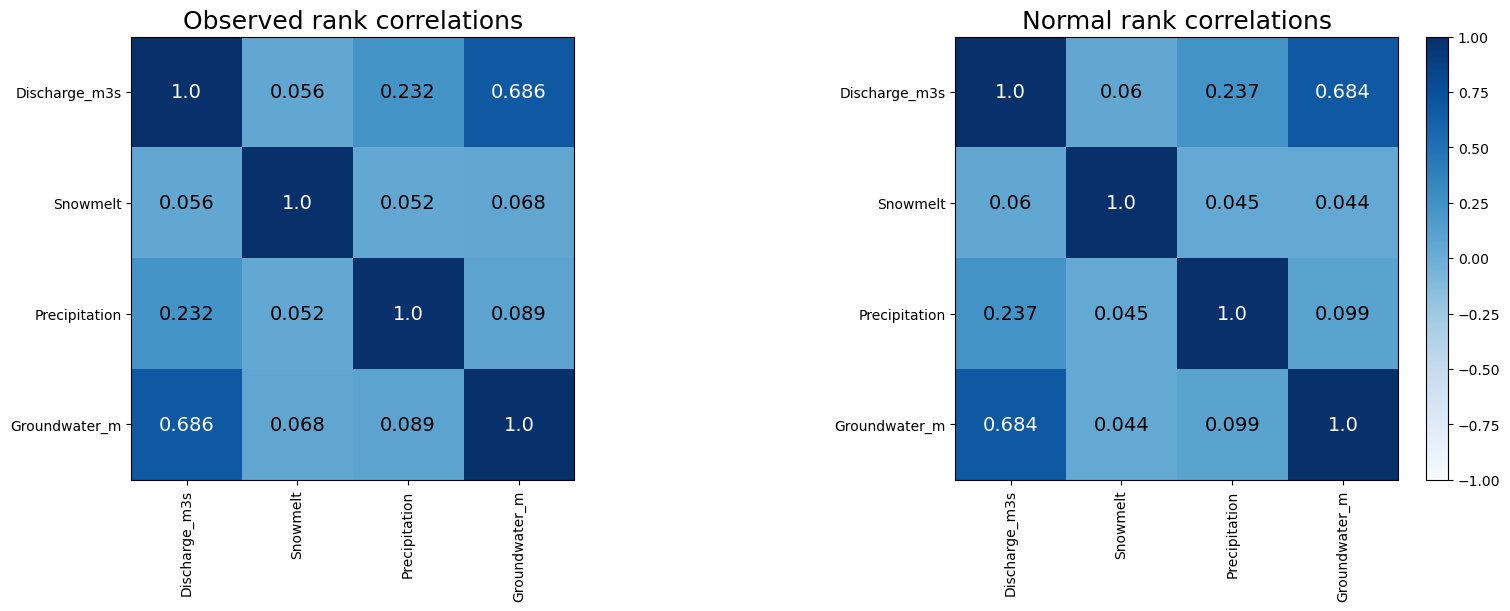

In [22]:
#Plot
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,2, figsize=(15,6), layout='constrained')
im1=axes[0].imshow(R_e, cmap='Blues', vmin=-1, vmax=1)
axes[0].set_xticks(px, nam, rotation=90)
axes[0].set_yticks(px, nam)
axes[0].set_title('Observed rank correlations',fontsize=18)
zz2 = np.round(R_e, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[0].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)

im1=axes[1].imshow(R_N, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_xticks(px, nam, rotation=90)
axes[1].set_yticks(px, nam)
axes[1].set_title('Normal rank correlations',fontsize=18)
zz2 = np.round(R_N, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[1].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)
        
cbar = fig.colorbar(im1,ax=axes[1], fraction=0.05, pad=0.04)

In [23]:
d_cal_E_N_full_year = 1 - test_distance(R_e, R_N, 'H', data.shape[1])
print('The d-calibration score between R_e and R_N is', d_cal_E_N_full_year.round(2))
d_cal_BN_N_full_year = 1 - test_distance(R_N, R_BN_1_seasonality_full_year, 'H', data.shape[1])
print('The d-calibration score between R_BN and R_N is', d_cal_BN_N_full_year.round(2))

The d-calibration score between R_e and R_N is [[0.99]]
The d-calibration score between R_BN and R_N is [[0.93]]


### Spring season analysis

#### NPBN + Time Lag

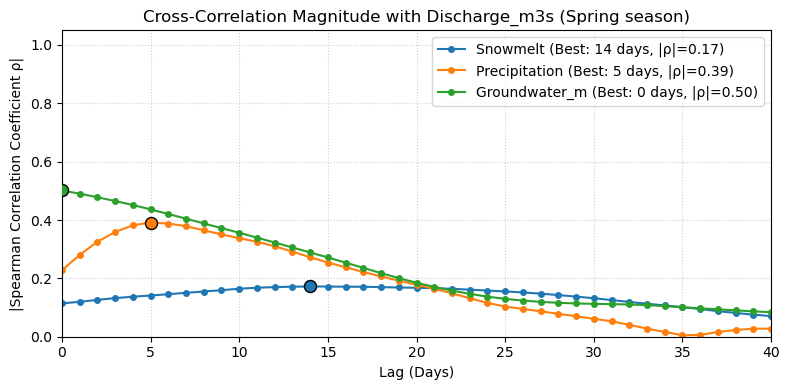

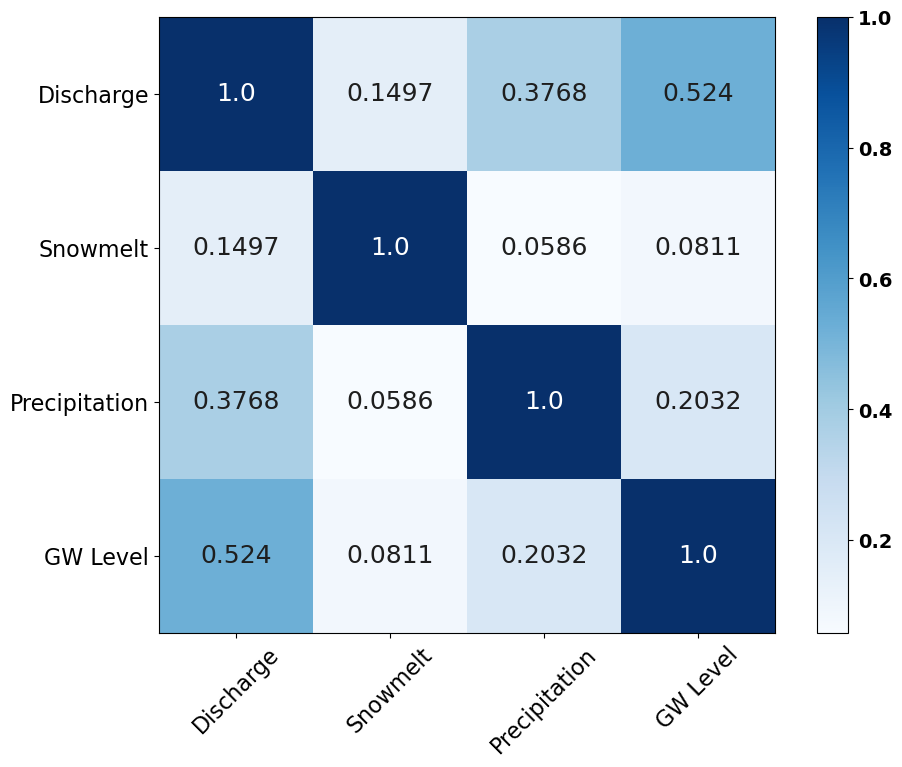

Optimal Shifts Found:
 - Snowmelt: 14 days
 - Precipitation: 5 days
 - Groundwater_m: 0 days


In [24]:
df_spring = df_final_seasonality[df_final_seasonality.index.month.isin([3, 4, 5, 6, 7])].copy()

target_var = 'Discharge_m3s'
parents = ['Snowmelt', 'Precipitation', 'Groundwater_m'] 

plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    if parent not in df_spring.columns:
        print(f"Warning: Column '{parent}' not found. Skipping.")
        continue
        
    lags, abs_corrs, best_k, max_r = analyze_lag(df_spring, target_var, parent)
    best_lags[parent] = best_k
    
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    color = p[0].get_color()
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

df_shifted_spring = df_spring.copy()
for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted_spring[col] = df_shifted_spring[col].shift(lag)
    else:
        pass
        
df_shifted_spring = df_shifted_spring.dropna()
plt.title(f'Cross-Correlation Magnitude with {target_var} (Spring season)')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show

R_BN_1_seasonality_spring = bn_rankcorr(parents1, df_shifted_spring, var_names=['Discharge', 'Snowmelt', 'Precipitation', 'GW Level'], is_data=True, plot=True)

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")


#### CvM statistic

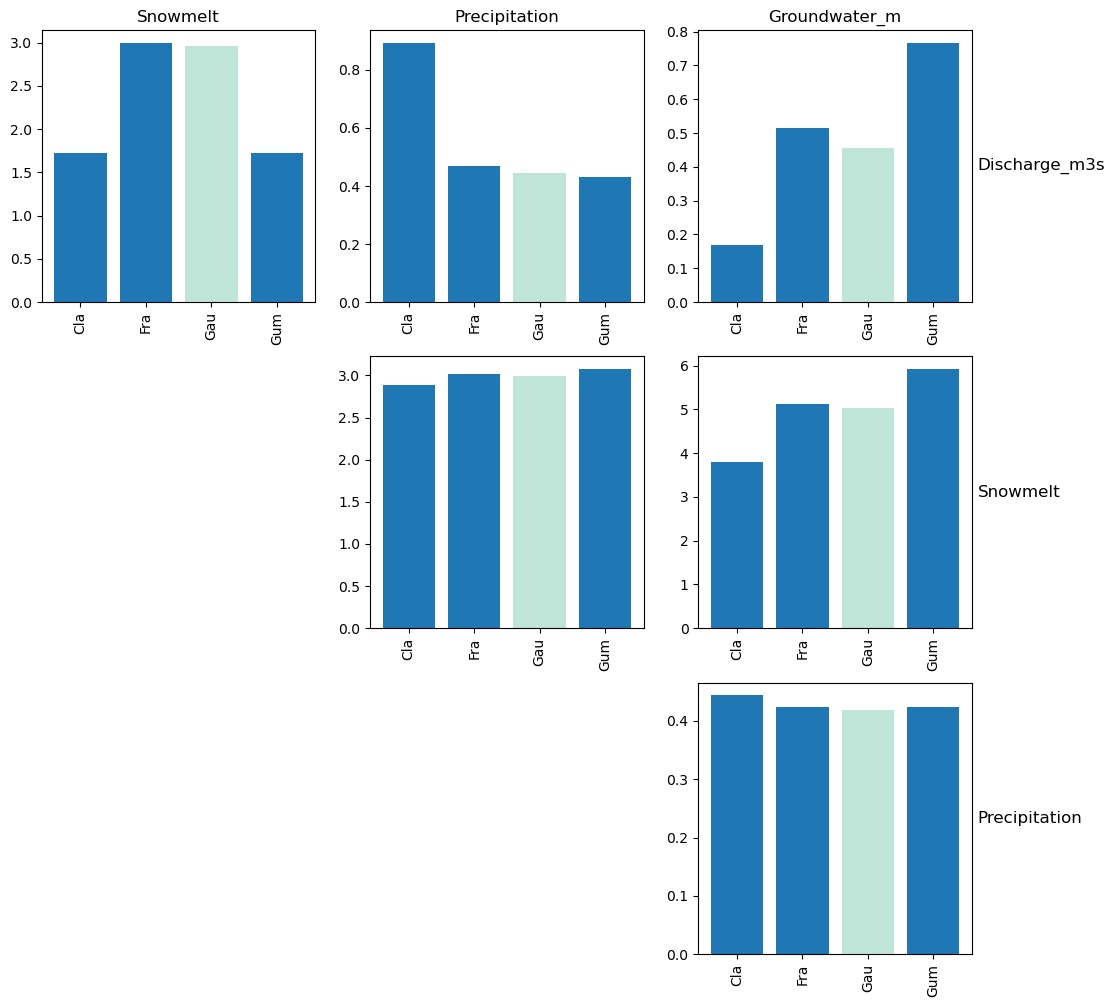

In [25]:
data_spring = df_final_seasonality[df_final_seasonality.index.month.isin([3, 4, 5, 6, 7])].copy()
unity_data_spring = unity(data_spring)

M = cvm_statistic(data_spring, plot=1, names=data.columns,fig_name='CvM')

#### Significance testing

In [26]:
standard_data_spring = pd.DataFrame(sd_normal(data_spring), columns=data_spring.columns)

rho_N_spring = np.corrcoef(standard_data_spring, rowvar=False) # PEARSON!

R_N_spring = 6 / np.pi * np.arcsin(rho_N_spring / 2)

R_e_spring = stats.spearmanr(data_spring)[0]

print(f'p-value: {stats.spearmanr(data_spring)[1]}')

p-value: [[0.00000000e+000 4.32976817e-006 2.09084123e-020 2.79186509e-103]
 [4.32976817e-006 0.00000000e+000 2.47264163e-001 3.81045667e-026]
 [2.09084123e-020 2.47264163e-001 0.00000000e+000 4.12673789e-001]
 [2.79186509e-103 3.81045667e-026 4.12673789e-001 0.00000000e+000]]


#### d-calibration scores

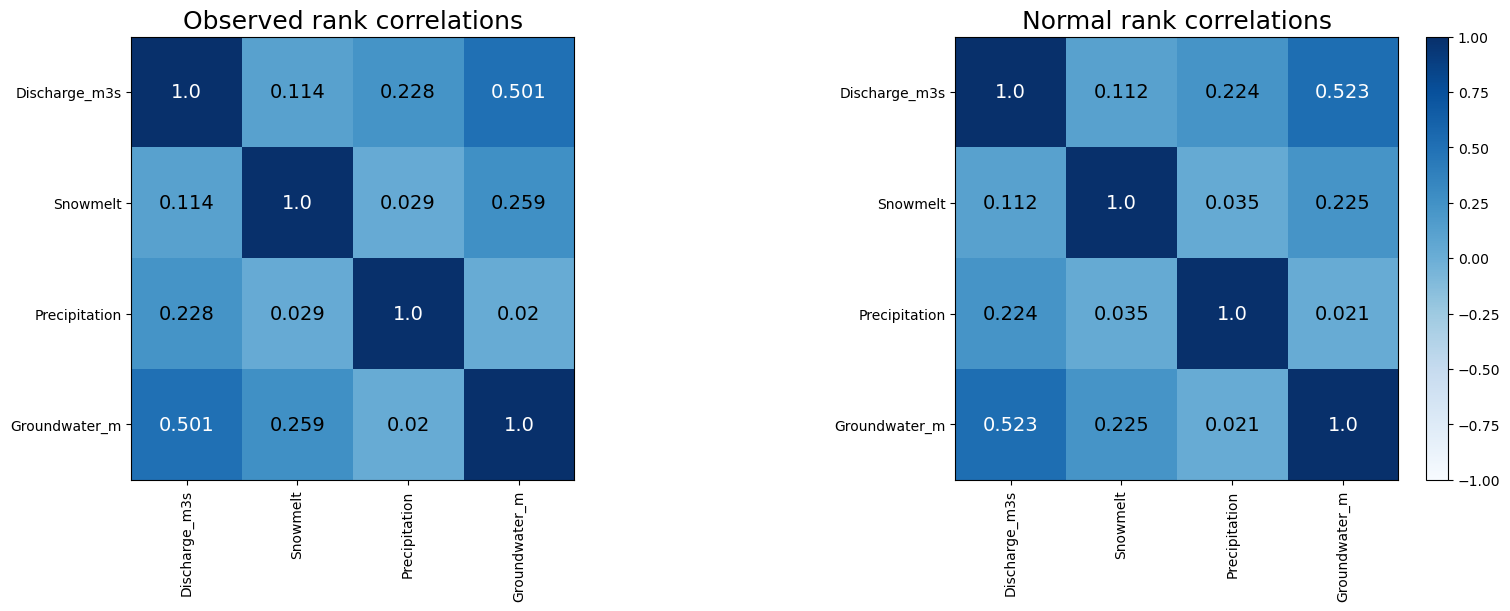

In [27]:
#Plot
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,2, figsize=(15,6), layout='constrained')
im1=axes[0].imshow(R_e_spring, cmap='Blues', vmin=-1, vmax=1)
axes[0].set_xticks(px, nam, rotation=90)
axes[0].set_yticks(px, nam)
axes[0].set_title('Observed rank correlations',fontsize=18)
zz2 = np.round(R_e_spring, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[0].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)

im1=axes[1].imshow(R_N_spring, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_xticks(px, nam, rotation=90)
axes[1].set_yticks(px, nam)
axes[1].set_title('Normal rank correlations',fontsize=18)
zz2 = np.round(R_N_spring, 3)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[1].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)
        
cbar = fig.colorbar(im1,ax=axes[1], fraction=0.05, pad=0.04)

In [28]:

d_cal_E_N_spring = 1 - test_distance(R_e_spring, R_N_spring, 'H', data_spring.shape[1])
print('The d-calibration score between R_e and R_N is', d_cal_E_N_spring.round(2))

d_cal_BN_N_spring = 1 - test_distance(R_N_spring, R_BN_1_seasonality_spring, 'H', data_spring.shape[1])
print('The d-calibration score between R_BN and R_N is', d_cal_BN_N_spring.round(2))

The d-calibration score between R_e and R_N is [[0.98]]
The d-calibration score between R_BN and R_N is [[0.9]]


## 6. Simulating Events

### Whole year simulation

Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making i

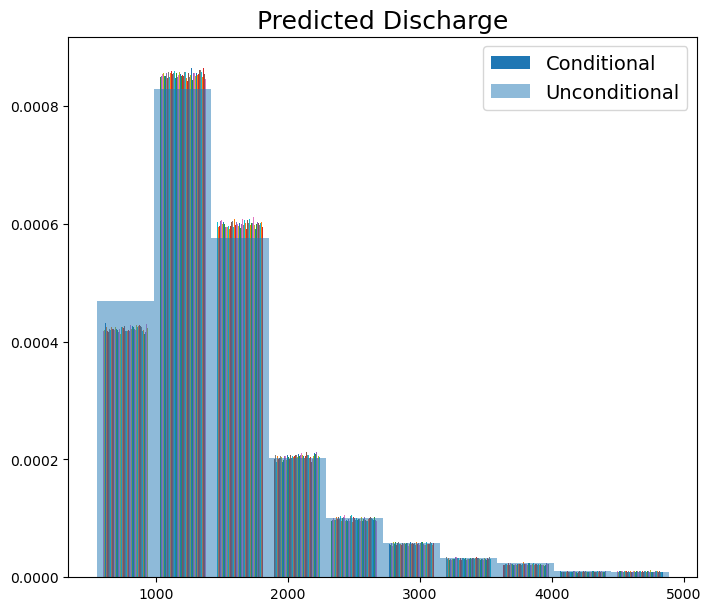

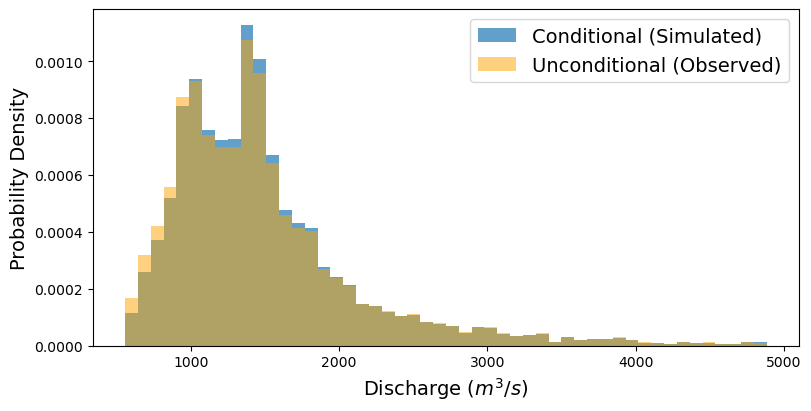

In [29]:
years = data.index.year.unique() 
n_years_sim = 100 

random_years = np.random.choice(years, size=n_years_sim, replace=True)

synthetic_inputs = []
for yr in random_years:
    yearly_data = data[data.index.year == yr].copy()
    synthetic_inputs.append(yearly_data)

synthetic_data = pd.concat(synthetic_inputs)

condition_nodes = [1, 2, 3]
condition_values = synthetic_data.iloc[:,1:4].to_numpy()

Q_pred = inference(Nodes = condition_nodes,
              Values = condition_values,
              R = R_BN_1_seasonality_full_year,
              DATA = data,
              empirical_data = True,
              SampleSize = 1000,
              Output = 'full').squeeze()

fig, axes = plt.subplots(1,1, figsize=(7,6), layout='constrained')
axes.hist(Q_pred, density = True, label = 'Conditional')
axes.hist(data.iloc[:,0], density = True, label = 'Unconditional', alpha = 0.5)
axes.set_title('Predicted Discharge',fontsize=18)
axes.legend(fontsize=14)

fig, axes = plt.subplots(1, 1, figsize=(8,4), layout='constrained')
axes.hist(Q_pred.flatten(), bins=50, density=True, label='Conditional (Simulated)', alpha=0.7)
axes.hist(data.iloc[:, 0], bins=50, density=True, label='Unconditional (Observed)', alpha=0.5, color='orange')
axes.set_xlabel('Discharge ($m^3/s$)', fontsize=14)
axes.set_ylabel('Probability Density', fontsize=14)
axes.legend(fontsize=14)
plt.show()

In [ ]:
init = 0
end = len(synthetic_data.index)

preds_list = []
for i in range(init, end):
    vals = synthetic_data.iloc[i, [1, 2, 3]].values.tolist()
    res = inference(Nodes = [1, 2, 3],
                    Values = vals,
                    R = R_BN_1_seasonality_full_year,
                    DATA = data,
                    empirical_data = True,
                    SampleSize = 1000,
                    Output = 'full').squeeze()
    preds_list.append(res)

Q_pred_matrix = np.array(preds_list) 

Q_median = np.quantile(Q_pred_matrix, 0.50, axis=1)

fig, ax = plt.subplots(figsize=(15, 6), layout='constrained')

ax.plot(range(end-init), synthetic_data.iloc[init:end,0], '--k', label = 'Observations')
ax.plot(Q_median, color='cornflowerblue', linewidth=0.5, label='Synthetic Discharge (Median)')
ax.plot(np.quantile(Q_pred_matrix, 0.05, axis=1), ':', color = 'cornflowerblue', label = '5% quantile')
ax.plot(np.quantile(Q_pred_matrix, 0.95, axis=1), ':', color = 'cornflowerblue', label = '95% quantile')

ax.set_xlabel('Synthetic Time (Days)', fontsize=14)
ax.set_ylabel('Discharge ($m^3/s$)', fontsize=14)
ax.set_title(f'Synthetic Simulation: {n_years_sim} Years', fontsize=16)
ax.legend()
plt.show()

#### Save simulation to .csv

In [ ]:
df_sim = pd.DataFrame({
    'index': range(len(Q_median)), 
    '50% confidence interval': Q_median
})

df_sim.to_csv('discharge_sim.csv', index=False)

File 'discharge_sim.csv' saved successfully.
   index  50% confidence interval
0      0              1590.899798
1      1              1712.900966
2      2              1631.127012
3      3              1631.695537
4      4              1676.964515


### Spring season simulation

Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making inference. Progress:  0%
Making i

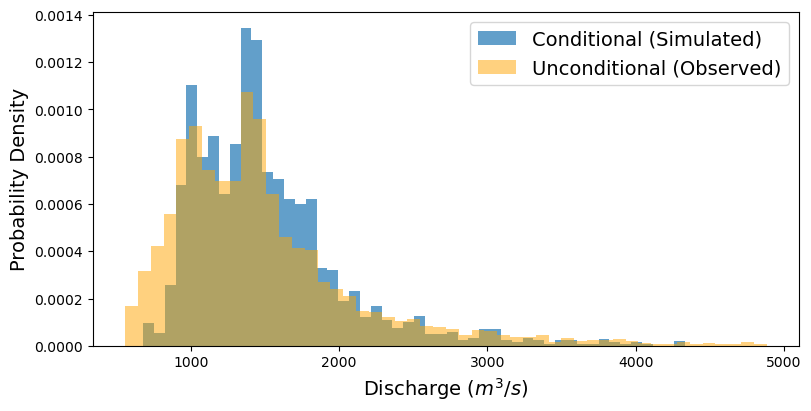

In [ ]:
years_spring = data_spring.index.year.unique() 
n_years_sim = 100 

random_years_spring = np.random.choice(years_spring, size=n_years_sim, replace=True)

synthetic_inputs_spring = []
for yr in random_years_spring:
    yearly_data = data_spring[data_spring.index.year == yr].copy()
    synthetic_inputs_spring.append(yearly_data)

synthetic_data_spring = pd.concat(synthetic_inputs_spring)

condition_nodes = [1, 2, 3]
condition_values = synthetic_data_spring.iloc[:,1:4].to_numpy()

Q_pred = inference(Nodes = condition_nodes,
              Values = condition_values,
              R = R_BN_1_seasonality_spring,
              DATA = data_spring,
              empirical_data = True,
              SampleSize = 1000,
              Output = 'full').squeeze()

fig, axes = plt.subplots(1, 1, figsize=(8,4), layout='constrained')

axes.hist(Q_pred.flatten(), bins=50, density=True, label='Conditional (Simulated)', alpha=0.7)
axes.hist(data.iloc[:, 0], bins=50, density=True, label='Unconditional (Observed)', alpha=0.5, color='orange')
axes.set_xlabel('Discharge ($m^3/s$)', fontsize=14)
axes.set_ylabel('Probability Density', fontsize=14)
axes.legend(fontsize=14)
plt.show()

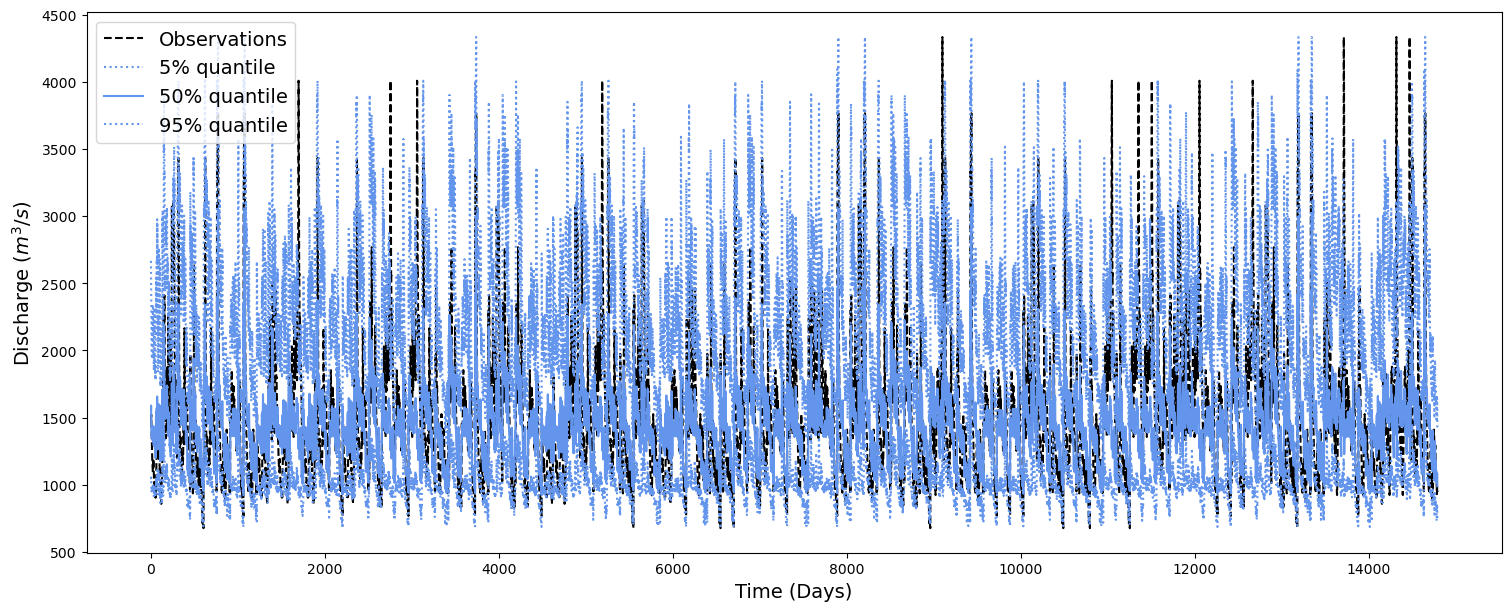

In [ ]:
init = 0
end = len(synthetic_data_spring.index)

preds_list = []
for i in range(init, end):
    vals = synthetic_data_spring.iloc[i, [1, 2, 3]].values.tolist()
    res = inference(Nodes = [1, 2, 3],
                    Values = vals,
                    R = R_BN_1_seasonality_spring,
                    DATA = data_spring,
                    empirical_data = True,
                    SampleSize = 1000,
                    Output = 'full').squeeze()
    preds_list.append(res)

Q_pred_matrix = np.array(preds_list) 

fig, axes = plt.subplots(1,1, figsize=(15,6), layout='constrained')
axes.plot(range(end-init), synthetic_data_spring.iloc[init:end,0], '--k', label = 'Observations')
axes.plot(np.quantile(Q_pred_matrix, 0.05, axis=1), ':', color = 'cornflowerblue', label = '5% quantile')
axes.plot(np.quantile(Q_pred_matrix, 0.5, axis=1), color = 'cornflowerblue', label = '50% quantile')
axes.plot(np.quantile(Q_pred_matrix, 0.95, axis=1), ':', color = 'cornflowerblue', label = '95% quantile')
axes.set_xlabel('Time (Days)', fontsize=14)
axes.set_ylabel('Discharge ($m^3/s$)', fontsize=14)
axes.legend(fontsize=14)
plt.show()

#### This is the end of this notebook.